In [1]:
import s3fs
import xarray as xr
import earthkit.plots as ekp

In [ ]:
S3_KEY = ""
S3_SECRET = ""

In [3]:
eodc_s3 = s3fs.S3FileSystem(
    key=S3_KEY,
    secret=S3_SECRET,
    client_kwargs={"endpoint_url": "https://objects.eodc.eu"},
)

open Tplus2.0K Level 2

In [4]:
store = eodc_s3.get_mapper(
    "destine-climate-dt/vsw/zarr/IFS_FESOM_story_nudging.zarr/Tplus2.0K/2"
)

In [5]:
ds = xr.open_zarr(store)


In [6]:
ds

<xarray.Dataset> Size: 68MB
Dimensions:      (realization: 5, time: 3287, points: 517)
Coordinates:
  * realization  (realization) int64 40B 1 2 3 4 5
  * time         (time) datetime64[ns] 26kB 2017-01-01T12:00:00 ... 2025-12-3...
  * points       (points) int32 2kB 0 1 2 3 4 5 6 ... 511 512 513 514 515 516
    latitude     (points) float64 4kB dask.array<chunksize=(517,), meta=np.ndarray>
    levelist     (points) float64 4kB dask.array<chunksize=(517,), meta=np.ndarray>
    longitude    (points) float64 4kB dask.array<chunksize=(517,), meta=np.ndarray>
Data variables:
    vsw          (realization, time, points) float64 68MB dask.array<chunksize=(5, 100, 517), meta=np.ndarray>
Attributes: (12/16)
    activity:     story-nudging
    class:        d1
    dataset:      climate-dt
    experiment:   tplus2.0k
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2017-01-01 12:00:00Z

In [10]:
vsw_snapshot = ds["vsw"].sel(realization=4, time="2022-01-01")

/home/koenifra/Projects/dt-climate-zarr/dt/lib/python3.11/site-packages/earthkit/plots/styles/__init__.py:623: UserWarning: The following kwargs were not used by contour: 'transform_first', 'title'
  return ax.tricontourf(x, y, values, *args, **kwargs)


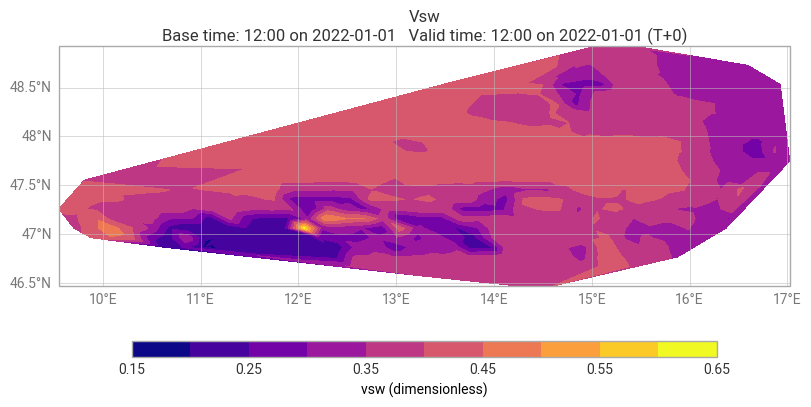

In [11]:
ekp.quickplot(
    vsw_snapshot,
    title="vsw — Tplus2.0K, level 2, realization 4, 2022-01-01",
)

In [45]:
store_Fesom = eodc_s3.get_mapper(
    "destine-climate-dt/vsw/zarr/IFS-FESOM.zarr/SSP3-7.0/3"
)

In [46]:
ds_fesom = xr.open_zarr(store_Fesom)
ds_fesom

<xarray.Dataset> Size: 212MB
Dimensions:    (time: 12784, points: 2067)
Coordinates:
  * time       (time) datetime64[ns] 102kB 2015-01-01T12:00:00 ... 2049-12-31...
  * points     (points) int32 8kB 0 1 2 3 4 5 ... 2061 2062 2063 2064 2065 2066
    latitude   (points) float64 17kB dask.array<chunksize=(2067,), meta=np.ndarray>
    levelist   (points) float64 17kB dask.array<chunksize=(2067,), meta=np.ndarray>
    longitude  (points) float64 17kB dask.array<chunksize=(2067,), meta=np.ndarray>
Data variables:
    vsw        (time, points) float64 211MB dask.array<chunksize=(100, 2067), meta=np.ndarray>
Attributes: (12/16)
    activity:     projections
    class:        d1
    dataset:      climate-dt
    experiment:   ssp3-7.0
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2015-01-01 12:00:00Z

In [47]:
vsw_snapshot = ds_fesom["vsw"].sel(time="2017-01-01")

/home/koenifra/Projects/dt-climate-zarr/dt/lib/python3.11/site-packages/earthkit/plots/styles/__init__.py:623: UserWarning: The following kwargs were not used by contour: 'transform_first', 'title'
  return ax.tricontourf(x, y, values, *args, **kwargs)


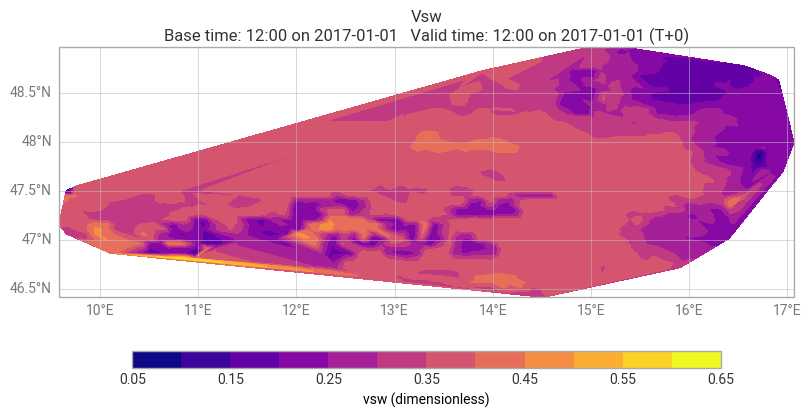

In [48]:
ekp.quickplot(
    vsw_snapshot,
    title="vsw — Tplus2.0K, level 2, realization 4, 2022-01-01",
)

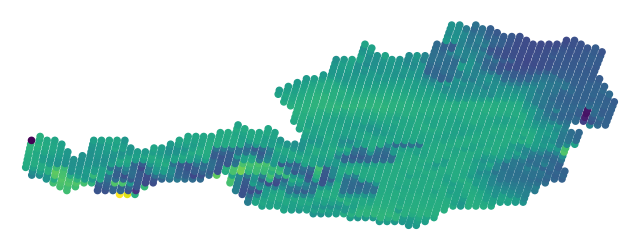

In [49]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(8, 6))
ax.set_extent([
    vsw_snapshot["longitude"].min() - 0.2, vsw_snapshot["longitude"].max() + 0.2,
    vsw_snapshot["latitude"].min() - 0.2, vsw_snapshot["latitude"].max() + 0.2,
], crs=ccrs.PlateCarree())

ax.scatter(
    vsw_snapshot["longitude"], vsw_snapshot["latitude"],
    c=vsw_snapshot.values, cmap="viridis", s=20,
    transform=ccrs.PlateCarree(),
)
ax.axis("off")
plt.show()


In [22]:
http_store = "https://objects.eodc.eu/68e13833a1624f43ba2cac01376a18af:destine-climate-dt/vsw/zarr/IFS-NEMO.zarr/hist/3"

In [23]:
http_ds = xr.open_zarr(http_store)
http_ds

<xarray.Dataset> Size: 151MB
Dimensions:    (time: 9131, points: 2067)
Coordinates:
  * time       (time) datetime64[ns] 73kB 1990-01-01T12:00:00 ... 2014-12-31T...
  * points     (points) int32 8kB 0 1 2 3 4 5 ... 2061 2062 2063 2064 2065 2066
    latitude   (points) float64 17kB dask.array<chunksize=(2067,), meta=np.ndarray>
    levelist   (points) float64 17kB dask.array<chunksize=(2067,), meta=np.ndarray>
    longitude  (points) float64 17kB dask.array<chunksize=(2067,), meta=np.ndarray>
Data variables:
    vsw        (time, points) float64 151MB dask.array<chunksize=(100, 2067), meta=np.ndarray>
Attributes: (12/16)
    activity:     baseline
    class:        d1
    dataset:      climate-dt
    experiment:   hist
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         1990-01-01 12:00:00Z